# Stock Price Prediction Using LSTM
## Minor Project | Part 2 — Data Preprocessing

### Objective
This notebook prepares the raw stock data for LSTM modeling. Steps include handling missing values, feature engineering, normalization using MinMaxScaler, and splitting the dataset into training, validation, and testing subsets.

> **INPUT**: Raw historical stock price CSV  
> **OUTPUT**: Scaled CSV files for train / validate / test + saved scaler

---

### 1. INITIALIZATION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models',         exist_ok=True)
print("Libraries loaded successfully.")

Libraries loaded successfully.


### 2. LOAD & CLEAN DATA

In [3]:
df = pd.read_csv('../data/raw/google_stock_price.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Raw dataset shape: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}")

# Drop any rows with missing values
df.dropna(inplace=True)
print(f"\nClean dataset shape: {df.shape}")
df.head()

Raw dataset shape: (2765, 6)
Missing values:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Clean dataset shape: (2765, 6)


,Date,Close,High,Low,Open,Volume
0,2015-01-02,26.260458,26.570396,26.177641,26.411706,26480000
1,2015-01-05,25.760094,26.183098,25.675296,26.141442,41182000
2,2015-01-06,25.124350,25.846876,25.070296,25.811668,54456000
3,2015-01-07,25.050459,25.364860,24.976075,25.338083,46918000
4,2015-01-08,25.137739,25.166996,24.548111,24.869952,73054000


### 3. FEATURE ENGINEERING

We enrich the dataset with technical indicators:
- **MA_10, MA_20**: Short-term momentum signals
- **MA_100, MA_200**: Long-term trend signals  
- **Daily_Return**: Percentage change from previous day
- **Price_Range**: Intra-day volatility (High - Low)

In [5]:
df['MA_10']        = df['Close'].rolling(10).mean()
df['MA_20']        = df['Close'].rolling(20).mean()
df['MA_100']       = df['Close'].rolling(100).mean()
df['MA_200']       = df['Close'].rolling(200).mean()
df['Daily_Return'] = df['Close'].pct_change()
df['Price_Range']  = df['High'] - df['Low']

# Drop rows with NaN from rolling windows
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Dataset shape after feature engineering: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Dataset shape after feature engineering: (2367, 12)

Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'MA_10', 'MA_20', 'MA_100', 'MA_200', 'Daily_Return', 'Price_Range']


,Date,Close,High,Low,Open,Volume,MA_10,MA_20,MA_100,MA_200,Daily_Return,Price_Range
0,2016-08-02,39.678062,39.787161,39.400855,39.539706,39928000,38.214904,37.210927,36.697322,36.770889,-0.001024,0.386307
1,2016-08-03,39.618553,39.649301,39.325973,39.497060,29206000,38.422390,37.433958,36.724125,36.796577,-0.001500,0.323328
2,2016-08-04,39.535740,39.682030,39.370605,39.584834,21520000,38.634835,37.657089,36.747438,36.820702,-0.002090,0.311425
3,2016-08-05,40.015766,40.030147,39.563503,39.677562,36146000,38.871131,37.878137,36.775387,36.852175,0.012142,0.466644
4,2016-08-08,39.931469,40.048997,39.755918,39.969651,24426000,39.107726,38.071613,36.799125,36.885259,-0.002107,0.293079


### 4. TRAIN / VALIDATION / TEST SPLIT

We use a **chronological** split — critical for time-series data to avoid look-ahead bias:
- **Train**: 70% of data (earliest)
- **Validate**: 15% of data (middle)
- **Test**: 15% of data (most recent)

In [6]:
n = len(df)
train_end    = int(n * 0.70)
validate_end = int(n * 0.85)

train_df    = df.iloc[:train_end].copy()
validate_df = df.iloc[train_end:validate_end].copy()
test_df     = df.iloc[validate_end:].copy()

print(f"Total samples   : {n}")
print(f"Training        : {len(train_df)}  ({len(train_df)/n*100:.1f}%)  {train_df['Date'].iloc[0].date()} → {train_df['Date'].iloc[-1].date()}")
print(f"Validation      : {len(validate_df)}  ({len(validate_df)/n*100:.1f}%)  {validate_df['Date'].iloc[0].date()} → {validate_df['Date'].iloc[-1].date()}")
print(f"Testing         : {len(test_df)}   ({len(test_df)/n*100:.1f}%)  {test_df['Date'].iloc[0].date()} → {test_df['Date'].iloc[-1].date()}")

Total samples   : 2367
Training        : 1656  (70.0%)  2016-08-02 → 2023-03-01
Validation      : 355  (15.0%)  2023-03-02 → 2024-07-30
Testing         : 356   (15.0%)  2024-07-31 → 2025-12-30


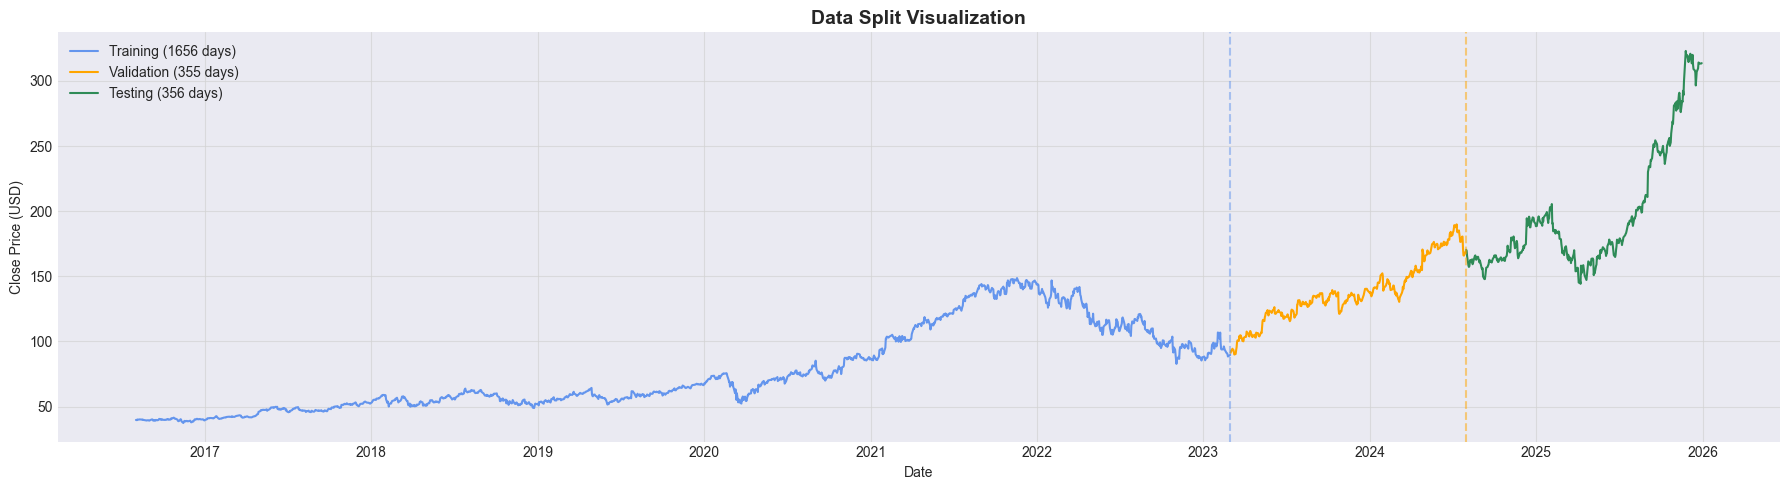

In [7]:
# Visualize the split
plt.figure(figsize=(18, 5))
plt.plot(train_df['Date'],    train_df['Close'],    color='cornflowerblue', label=f'Training ({len(train_df)} days)',    linewidth=1.5)
plt.plot(validate_df['Date'], validate_df['Close'], color='orange',         label=f'Validation ({len(validate_df)} days)', linewidth=1.5)
plt.plot(test_df['Date'],     test_df['Close'],     color='seagreen',       label=f'Testing ({len(test_df)} days)',     linewidth=1.5)
plt.axvline(train_df['Date'].iloc[-1],    color='cornflowerblue', linestyle='--', alpha=0.5)
plt.axvline(validate_df['Date'].iloc[-1], color='orange',         linestyle='--', alpha=0.5)
plt.title('Data Split Visualization', fontsize=14, fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Close Price (USD)')
plt.legend(); plt.grid(color='lightgray', alpha=0.7)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('../data/processed/split_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

### 5. FEATURE SCALING (MinMaxScaler)

**Important**: The scaler is **fitted ONLY on training data** and then applied to validation and test sets. Fitting on the full dataset would cause **data leakage** — a common mistake that inflates model performance.

In [9]:
features = ['Open', 'High', 'Low', 'Close', 'Volume',
            'MA_10', 'MA_20', 'MA_100', 'MA_200', 'Daily_Return', 'Price_Range']

scaler = MinMaxScaler(feature_range=(0, 1))

# Fit ONLY on training data — prevents data leakage
train_scaled    = scaler.fit_transform(train_df[features])
validate_scaled = scaler.transform(validate_df[features])
test_scaled     = scaler.transform(test_df[features])

print(f"Features scaled: {features}")
print(f"Scaler fitted on training data only ({len(train_df)} rows)")
print(f"Train scaled shape    : {train_scaled.shape}")
print(f"Validate scaled shape : {validate_scaled.shape}")
print(f"Test scaled shape     : {test_scaled.shape}")

Features scaled: ['Open', 'High', 'Low', 'Close', 'Volume', 'MA_10', 'MA_20', 'MA_100', 'MA_200', 'Daily_Return', 'Price_Range']
Scaler fitted on training data only (1656 rows)
Train scaled shape    : (1656, 11)
Validate scaled shape : (355, 11)
Test scaled shape     : (356, 11)


### 6. SAVE PROCESSED DATASETS & SCALER

In [11]:
# Save as DataFrames with Date column
train_out    = pd.DataFrame(train_scaled,    columns=features)
validate_out = pd.DataFrame(validate_scaled, columns=features)
test_out     = pd.DataFrame(test_scaled,     columns=features)

train_out.insert(0,    'Date', train_df['Date'].values)
validate_out.insert(0, 'Date', validate_df['Date'].values)
test_out.insert(0,     'Date', test_df['Date'].values)

train_out.to_csv('../data/processed/google_stock_price_processed_train.csv',    index=False)
validate_out.to_csv('../data/processed/google_stock_price_processed_validate.csv', index=False)
test_out.to_csv('../data/processed/google_stock_price_processed_test.csv',      index=False)

# Save scaler
joblib.dump(scaler, '../models/google_stock_price_scaler.gz')

print("Saved:")
print("  data/processed/google_stock_price_processed_train.csv")
print("  data/processed/google_stock_price_processed_validate.csv")
print("  data/processed/google_stock_price_processed_test.csv")
print("  models/google_stock_price_scaler.gz")

Saved:
  data/processed/google_stock_price_processed_train.csv
  data/processed/google_stock_price_processed_validate.csv
  data/processed/google_stock_price_processed_test.csv
  models/google_stock_price_scaler.gz


### 7. PREPROCESSING SUMMARY

| Step | Action |
|---|---|
| Missing Values | Dropped NaN rows (from rolling windows) |
| Feature Engineering | Added MA_10, MA_20, MA_100, MA_200, Daily_Return, Price_Range |
| Split Strategy | Chronological 70/15/15 train/validate/test |
| Scaling | MinMaxScaler fitted on training set only (no leakage) |
| Total Features | 12 input features |
